In [1]:
import geopandas as gpd
from shapely.ops import snap
import networkx as nx
from shapely.geometry import Point
import numpy as np
from pysheds.grid import Grid
import pandas as pd

In [2]:
watershed = gpd.read_file("GIS/WATERSHEDS_CLIPPED.geojson")
watershed = watershed[watershed['NAME'] == 'Popes Head Creek']
watershed = watershed.to_crs('EPSG:26918')

In [3]:
grid = Grid.from_raster("elevation/popes_head_dem.tif")
dem = grid.read_raster("elevation/popes_head_dem.tif")

In [4]:
s14 = gpd.read_file('stormnet/14.geojson')
s14 = s14.to_crs(watershed.crs).clip(watershed)

# s14['YEAR_BUILT'] = pd.to_datetime(s14.CREATION_DATE, unit='ms').dt.year
# s14['YEAR_BUILT'] = s14['YEAR_BUILT'].fillna(s14.YEAR_BUILT.median()).astype(int)

<Axes: >

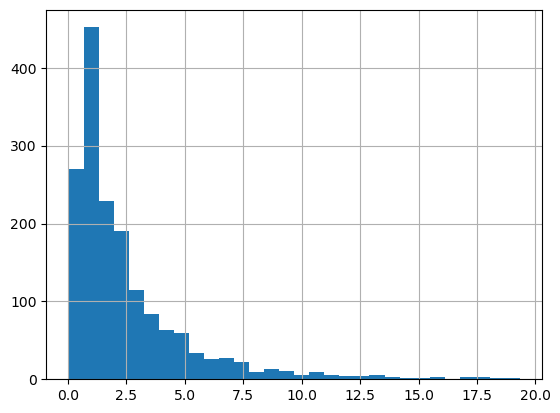

In [5]:
s14.SLOPE[(s14.SLOPE > 0) & (s14.SLOPE < 20)].hist(bins=30)

In [6]:
def get_index(x, y):
    j, i = ~grid.affine * (x, y)
    return int(i), int(j)

G = nx.DiGraph()
for idx, row in s14.iterrows():
    if row.geometry.geom_type != 'LineString':
        continue
    line = row.geometry
    
    start_point = Point(line.coords[0])
    end_point = Point(line.coords[-1])
    
    start_id = (round(start_point.x, 3), round(start_point.y, 3))
    end_id = (round(end_point.x, 3),round(end_point.y, 3))

    G.add_node(start_id, x=start_point.x, y=start_point.y)
    G.add_node(end_id, x=end_point.x,   y=end_point.y)

    G.add_edge(
        start_id,
        end_id,
        pipe_id=row["STORMNET_ID"],
        start_node=start_id,
        end_node=end_id,
        # length=row["ASSETLENGTH"],
        slope=row["SLOPE"],
        diameter=row["HEIGHT_DIA"],
        material=row["MATERIAL"],
        geometry=line,
        # year_built=row['YEAR_BUILT']
    )


In [7]:
for node in list(G.nodes):
    if G.out_degree(node) == 0 and G.in_degree(node) > 1:
        preds = list(G.predecessors(node))
        keeper = preds[0]
        for p in preds[1:]: # artificially reroute from outlet to junction for SWMM
            data = G.get_edge_data(p, node)
            data['end_node'] = keeper
            G.remove_edge(p, node)
            G.add_edge(
                p, keeper,
                **data
            )
    elif G.out_degree(node) == 0 and G.in_degree(node) == 0:
        G.remove_node(node)

In [8]:
infalls = []
outfalls = []

for node in G.nodes:
    x, y = G.nodes[node]['x'], G.nodes[node]['y']
    j, i = ~grid.affine * (x, y)
    i, j = int(i), int(j)
    elevation = dem[i, j]
    if elevation == dem.nodata:
        elevation = None
    G.nodes[node]['elevation'] = elevation
    if G.out_degree(node) == 0:
        outfalls.append(node)
        G.nodes[node]['node_type'] = 'outfall'
    elif G.in_degree(node) == 0:
        infalls.append(node)
        G.nodes[node]['node_type'] = 'infall'
    else:
        G.nodes[node]['node_type'] = 'junction'

print(f"Number of infalls: {len(infalls)}")
print(f"Number of outfalls: {len(outfalls)}")


Number of infalls: 1389
Number of outfalls: 961


In [9]:
node_geoms = []
node_records = []

for n, data in G.nodes(data=True):
    rec = {k: v for k, v in data.items() if k != "x" and k != "y"}
    rec["node_id"] = n
    node_records.append(rec)
    node_geoms.append(Point(data["x"], data["y"]))

nodes_gdf = gpd.GeoDataFrame(
    node_records,
    geometry=node_geoms,
    crs=s14.crs
)
median_elevation = nodes_gdf.elevation.median() # fill nan
nodes_gdf.elevation = nodes_gdf.elevation.fillna(median_elevation)

edge_geoms = []
edge_records = []

for u, v, data in G.edges(data=True):
    geom = data["geometry"]
    rec = {k: v for k, v in data.items() if k != "geometry"}
    
    edge_geoms.append(geom)
    edge_records.append(rec)

edges_gdf = gpd.GeoDataFrame(edge_records, geometry=edge_geoms, crs=s14.crs)
edges_gdf['slope'] = edges_gdf.slope.clip(0.1, 20).fillna(0.1) # require a minimum slope of 0.1%
edges_gdf['diameter'] = (edges_gdf.diameter.fillna(edges_gdf.diameter.median()) / 39.37) # convert inches to meters
edges_gdf.loc[edges_gdf.diameter < 0, "diameter"] =  edges_gdf.diameter[edges_gdf.diameter > 0].median()

In [10]:
# reconstruct graph to find invert elevations
G = nx.DiGraph()

for idx, row in nodes_gdf.iterrows():
    node_id = tuple(row["node_id"])
    G.add_node(node_id, geom=row["geometry"])

for idx, row in edges_gdf.iterrows():
    start = tuple(row["start_node"])
    end = tuple(row["end_node"])

    line = row["geometry"]
    length = line.length

    slope_percent = row["slope"]
    slope_decimal = slope_percent / 100.0

    drop = slope_decimal * length

    G.add_edge(start, end,
                length=length,
                slope=slope_decimal,
                drop=drop,
                pipe_id=row["pipe_id"],
                geom=line)

In [11]:
nodes = list(G.nodes())
node_idx = {n: i for i, n in enumerate(nodes)}

outfalls = [n for n in nodes if G.out_degree(n) == 0]

from collections import deque

paths = {n: [] for n in nodes}

for o in outfalls:
    queue = deque([(o, 0.0)])
    visited = set([o])

    while queue:
        curr, acc = queue.popleft()
        paths[curr].append((o, acc))

        for pred in G.predecessors(curr):
            drop = G.edges[pred, curr]["drop"]
            if pred not in visited:
                visited.add(pred)
                queue.append((pred, acc + drop))

num_nodes = len(nodes)
A_rows = []
b_vals = []

for n in nodes:
    n_i = node_idx[n]

    for o, cum_drop in paths[n]:
        o_i = node_idx[o]

        row = np.zeros(num_nodes)
        row[n_i] = 1.0       # z_n
        row[o_i] = -1.0      # -z_o

        A_rows.append(row)
        b_vals.append(cum_drop)

A = np.vstack(A_rows)
b = np.array(b_vals)

sol, *_ = np.linalg.lstsq(A, b, rcond=None)
node_elev = {n: sol[node_idx[n]] for n in nodes}


In [12]:
for n in nodes_gdf.node_id:
    invert = node_elev[n]
    if invert < 1e-3:
        invert = 0
    nodes_gdf.loc[nodes_gdf.node_id == n, "invert_elevation"] = invert

In [13]:
nodes_gdf.to_file("nodes.geojson", driver="GeoJSON")
edges_gdf.to_file("edges.geojson", driver="GeoJSON")